## Gradient Descent

- Gradient Descent is the first order  iterative otimization technique which is  used to find the local minimum of any function

In [2]:
from sklearn.datasets import make_regression
import numpy as np

In [3]:
X,y= make_regression(n_samples=3,n_features=1,n_informative=1,noise=80,random_state=13)

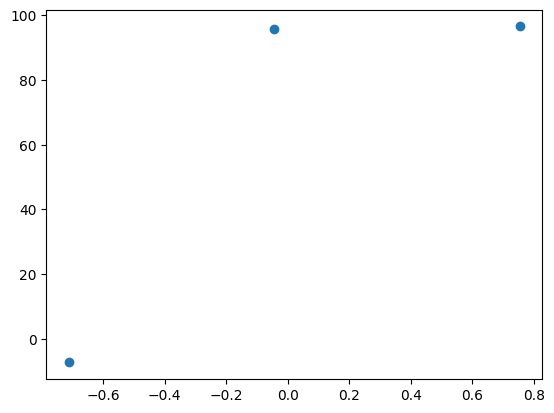

In [4]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [5]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
model.coef_

array([68.51966386])

In [7]:
model.intercept_

np.float64(61.74453127946609)

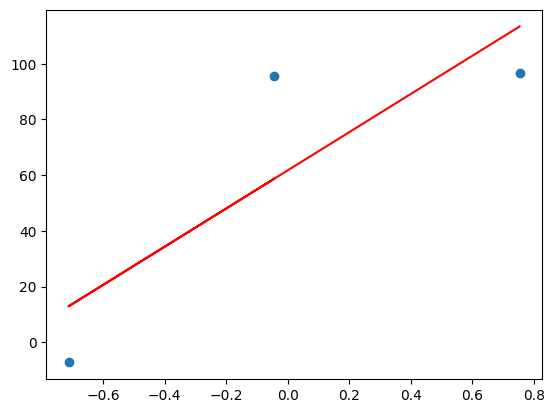

In [8]:
plt.scatter(X,y)
plt.plot(X,model.predict(X),color ='red')

### Lets apply gradient descent and find the best fit line for the time beign  lets take the slope as constant m=38.0931
- Lets assume the starting value of X_intercept as b = 0
-y_pred = mx+c
-Y_pred = ((38.0931*X)+0)

In [9]:
Y_pred = ((68.5196*X)+0)

In [10]:
type(Y_pred)

numpy.ndarray

In [11]:
Y_pred

array([[ -3.04933313],
       [-48.81272321],
       [ 51.64777076]])

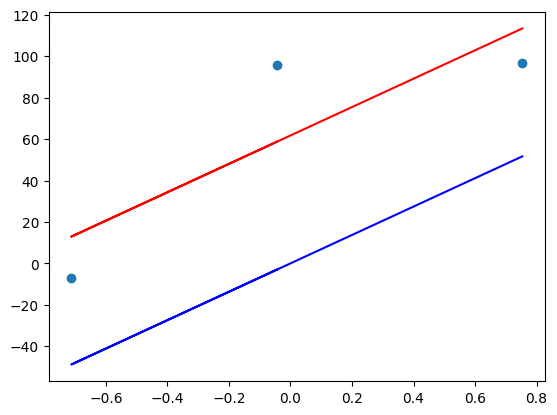

In [12]:
plt.scatter(X,y)
plt.plot(X,model.predict(X),color ='red')
plt.plot(X,Y_pred,color ='blue')

### Mathmatics 

- we had  the loss  function as
$L = \sum_{i=1}^{n}(y_i-\hat{y_i})^2$


$$\frac{\partial L}{\partial b} = \sum_{i=1}^{n}\frac{\partial((y_i-\hat{y_i})^2)}{\partial b}
$$

$$\frac{\partial L}{\partial b} = \sum_{i=1}^{n}\frac{\partial((y_i-mx_i-b)^2)}{\partial b}
$$

$$
\frac{\partial}{\partial b}
\sum_{i=1}^{n}
\left(y_i - mx_i - b\right)^2
=
\sum_{i=1}^{n}
2\left(y_i - mx_i - b\right)(-1)
$$

$$
loss slope=-2\sum_{i=1}^{n}
\left(y_i - mx_i - b\right)
$$

$
- Ƞ is  the learning rate
- step_size = loss_slope*Ƞ
- $b_\text{new} = b-step_size$
$

so now we will keep the slope constant and we will change the b to see 


In [13]:
b=0
# this this as the starting pint
m=68.5196
b=0
loss_slope=-2*np.sum(y-m*X-b)

In [14]:
loss_slope

np.float64(-1111.4015618320202)

### since it is clear that the difference is large so we multiplty the slope*Ƞ so that there is less difference 

#### This Ƞ is called learning rate

In [15]:
lr=0.01
step_size = loss_slope*lr
step_size

np.float64(-11.114015618320202)

In [16]:
b=b-step_size
b

np.float64(11.114015618320202)

### New Y_pred

In [17]:
y_pred= ((68.5196*X)+b)

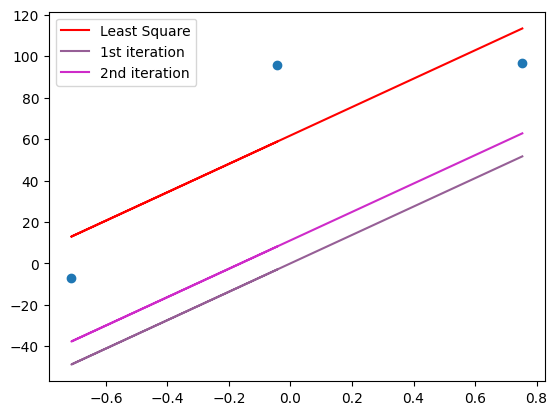

In [18]:
plt.scatter(X,y)
plt.plot(X,model.predict(X),color ='red',label='Least Square')
plt.plot(X,Y_pred,color ="#965F96",label='1st iteration')
plt.plot(X,y_pred,color = "#CE2BC9",label='2nd iteration')
plt.legend()



#### now we will do the same

In [19]:
b

np.float64(11.114015618320202)

In [20]:
loss_slope=-2*np.sum(y-m*X+b)
lr=0.01
step_size = loss_slope*lr
step_size


np.float64(-13.114538429617838)

In [21]:
b = b-step_size
b

np.float64(24.22855404793804)

In [22]:
y_pred_3= ((68.5196*X)+b)

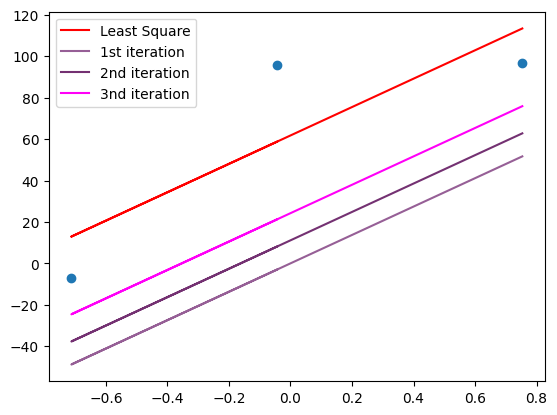

In [23]:
plt.scatter(X,y)
plt.plot(X,model.predict(X),color ='red',label='Least Square')
plt.plot(X,Y_pred,color ="#965F96",label='1st iteration')
plt.plot(X,y_pred,color = "#743172",label='2nd iteration')
plt.plot(X,y_pred_3,color = "#FF00F7",label='3nd iteration')
plt.legend()

In [24]:
b

np.float64(24.22855404793804)

In [25]:
loss_slope=-2*(np.sum(y-m*X+b))
loss_slope


np.float64(-1547.515534694905)

In [26]:
lr=0.01
step_size = lr*loss_slope
step_size

np.float64(-15.47515534694905)

In [27]:
b=b-step_size
b

np.float64(39.70370939488709)

In [28]:
y_pred_4=((68.5196*X)+b)

In [29]:
y_pred_4

array([[36.65437627],
       [-9.10901381],
       [91.35148015]])

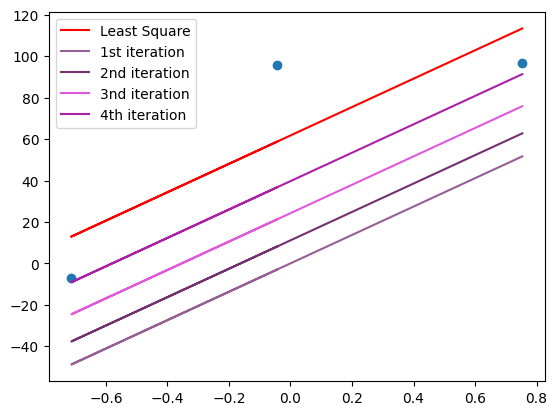

In [30]:
plt.scatter(X,y)
plt.plot(X,model.predict(X),color ='red',label='Least Square')
plt.plot(X,Y_pred,color ="#965F96",label='1st iteration')
plt.plot(X,y_pred,color = "#743172",label='2nd iteration')
plt.plot(X,y_pred_3,color = "#E059DC",label='3nd iteration')
plt.plot(X,y_pred_4,color = "#AB20A6",label='4th iteration')
plt.legend()

In [31]:
loss_slope=-2*((np.sum(y-m*X+b)))
loss_slope

np.float64(-1826.0683309399878)

In [32]:
step_size=lr*loss_slope

In [33]:
b = b-step_size

In [34]:
b

np.float64(57.96439270428697)

In [35]:
y_pred_5=((68.5196*X)+b)

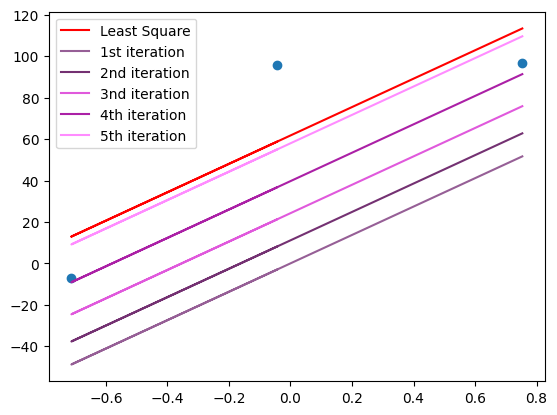

In [36]:
plt.scatter(X,y)
plt.plot(X,model.predict(X),color ='red',label='Least Square')
plt.plot(X,Y_pred,color ="#965F96",label='1st iteration')
plt.plot(X,y_pred,color = "#743172",label='2nd iteration')
plt.plot(X,y_pred_3,color = "#E059DC",label='3nd iteration')
plt.plot(X,y_pred_4,color = "#AB20A6",label='4th iteration')
plt.plot(X,y_pred_5,color="#FF8CFF",label='5th iteration')

plt.legend()

#### Last Iteration

In [37]:
loss_slope=-2*((np.sum(y-m*X+b)))

In [38]:
lr

0.01

In [39]:
step_size=lr*loss_slope

In [40]:
b= b-step_size

In [41]:
y_pred_6=((68.5196*X)+b)

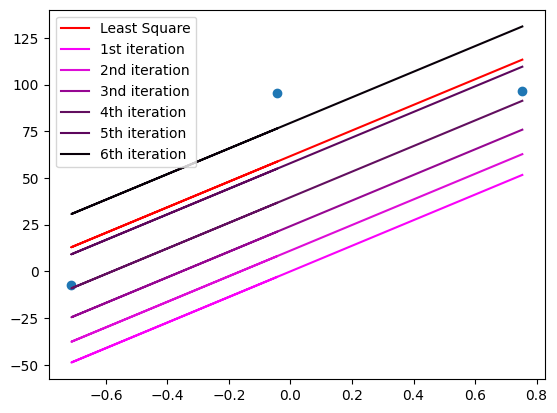

In [42]:
plt.scatter(X,y)
plt.plot(X,model.predict(X),color ='red',label='Least Square')
plt.plot(X,Y_pred,color ="#F902F9",label='1st iteration')
plt.plot(X,y_pred,color = "#DD0DD6",label='2nd iteration')
plt.plot(X,y_pred_3,color = "#960792",label='3nd iteration')
plt.plot(X,y_pred_4,color = "#620F5F",label='4th iteration')
plt.plot(X,y_pred_5,color="#5D075D",label='5th iteration')
plt.plot(X,y_pred_6,color="#090009",label='6th iteration')

plt.legend()

### Now we will do it  iteratively

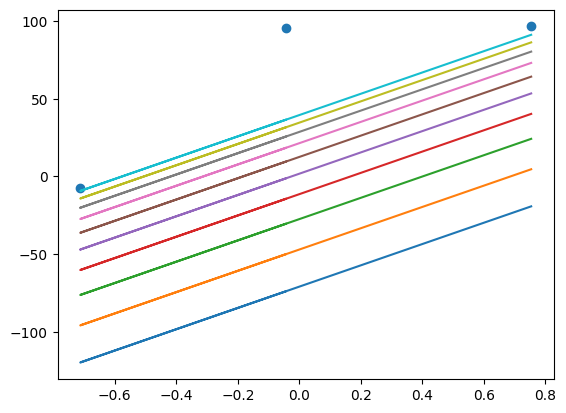

In [43]:
b =-100
m=68.5196
lr=0.01
epoch=10
for i in range(epoch):
    loss_slope=-2*np.sum(y-m*X-b)
    b=b-lr*loss_slope
    Y_pred= m*X+b
    plt.plot(X,Y_pred)
plt.scatter(X,y)

In [44]:
class GDReegressor:
    def __init__(self,learning_rate,epochs):
        self.m=m
        self.b=b
        self.lr=learning_rate
        self.epochs=epochs
    def fit(self,X,y):
        #calculate the b  using GD
        for i in range (self.epochs):
            loss_slope=-2*(np.sum(y-self.m*X-self.b))
            self.b=b-(self.lr*loss_slope)
            print(loss_slope,self.b)
            


        


In [45]:
gd=GDReegressor(0.00001,1000)
gd.fit(X,y)


-400.16641310225197 39.51706548245148
-400.09438314789355 39.51706476215193
-400.09439611328537 39.517064762281585
-400.0943961109516 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.517064762281564
-400.09439611095206 39.51706

### Gradient Descent with both solpe and intercept as the variable

- we  initialize the values of m and b
- lets take m =1 and b = 0
- for i in range of ephoces
- b = b- $Ƞ*m_b$
- m = m - Ƞ*$m_m$

$$
L = \sum_{i=1}^n(y_i - \hat{y_i})^2 = \sum(y-mx_i-b)^2
$$
$$
L(m,b) = \sum_{i=1}^n\frac{\partial(y-mx_i-b)^2}{\partial(m)} +  \sum_{i=1}^n\frac{\partial(y-mx_i-b)^2}{\partial(b)}
$$
$$

$$
L(m,b) =\underbrace{-2\sum(y-mx_i-b)}_{\text{with respect to m}} + \underbrace{-2\sum(y-mx_i-b)x_i}_{\text{with respect to b}}
$$

In [46]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as  np

In [47]:
X,y =  make_regression(n_samples=200,n_features= 1,n_informative= 1,n_targets=1,noise=100,random_state=42)

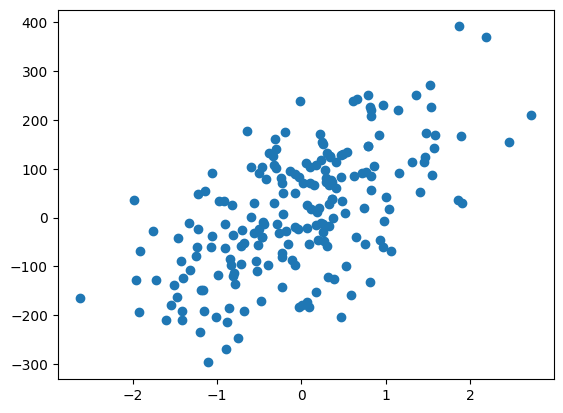

In [48]:
plt.scatter(X,y)

In [49]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
model.coef_

array([84.02843392])

In [51]:
model.intercept_

np.float64(14.285139010211896)

In [52]:
plt.bar

<function matplotlib.pyplot.bar(x: 'float | ArrayLike', height: 'float | ArrayLike', width: 'float | ArrayLike' = 0.8, bottom: 'float | ArrayLike | None' = None, *, align: "Literal['center', 'edge']" = 'center', data=None, **kwargs) -> 'BarContainer'>

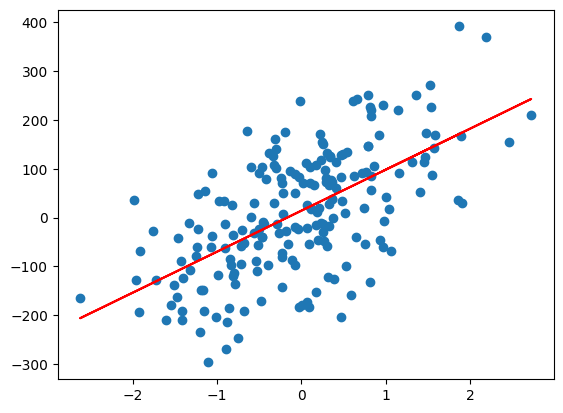

In [53]:
plt.scatter(X,y)
plt.plot(X,model.predict(X),color="red")

In [54]:
class GDregression :
    def __init__(self,learning_rate,epochs):
        self.m = 1
        self.b = -1
        self.lr = learning_rate
        self.epochs=epochs
    def fit(self,X,y):
        self.n =  len(X)
        for i in range(self.epochs):
            y_pred = self.m * X.ravel() + self.b
            db = (-2/self.n) * np.sum(y - y_pred)
            dm = (-2/self.n) * np.sum((y - y_pred) * X.ravel())
            self.b = self.b - self.lr * db
            self.m = self.m - self.lr * dm
        print(self.m)
        print(self.b)
    def predict(self,X_test):
        Y = self.m*X_test+self.b
        return Y





In [55]:
model2 = GDregression(learning_rate=0.001,epochs=3000)
model2.fit(X,y)

83.54011975437244
14.167639138596364


In [56]:
import numpy as np
import matplotlib.pyplot as plt

class GDregression:

    def __init__(self, learning_rate, epochs):
        self.m = 1
        self.b = -1
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X, y):

        self.n = len(X)

        plt.scatter(X, y, color='red')
    

        for i in range(self.epochs):
        

            y_pred = self.m * X.ravel() + self.b

            db = (-2/self.n) * np.sum(y - y_pred)
            dm = (-2/self.n) * np.sum((y - y_pred) * X.ravel())

            self.b = self.b - self.lr * db
            self.m = self.m - self.lr * dm

            # draw line after every epoch
            plt.plot(
                X,
                self.m * X.ravel() + self.b,
                alpha=0.3,
                label=f"epoch {i+1}"
            )
            

        
        plt.show()

    def predict(self, X_test):
        return self.m * X_test + self.b

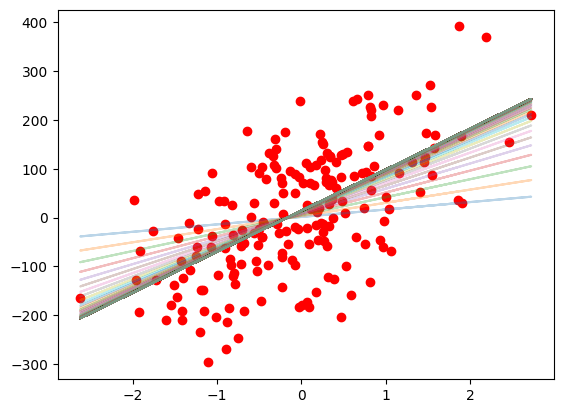

In [57]:
model2 = GDregression(learning_rate=0.1,epochs=300)
model2.fit(X,y)
pred = model2.predict(X)


In [58]:
Y_res = model2.predict(X)

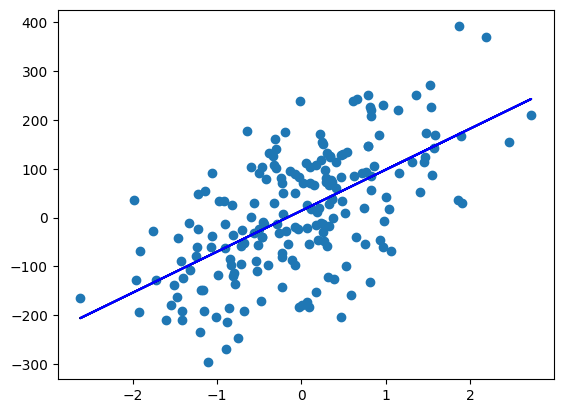

In [59]:

plt.scatter(X,y)
plt.plot(X,model.predict(X),color='black')
plt.plot(X,Y_res,color='blue')






## Batch Gradient Descent


- In batch Gradient descent we use all the available data for the calculaion
- It is computational not efficient

- The Above was the batch gradient desscent only now we will learn for more thant two data

So we took  our cgpa iq and lpa data 
$$
y =β_0 +β_1X_1 +β_2X_2
$$

$$
L = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

- so now our loss function's slope will have 3 componts
- Starting with  $β_0 =0, β_1=1,β_2=2$

epoch =100
Ƞ = 0.01

- $β_0 =β_0+Ƞ*sope$
- $β_1 =β_1+Ƞ*sope$
- $β_2 =β_2+Ƞ*sope$




#### Lets consider this as our data

| x₁ | x₂ | y |
|----|----|---|
| 8.1 | 9.3 | 3.2 |
| 7.5 | 9.5 | 3.5 |

### The value of n in this case will become 2

$$
L = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

$$
L = \frac{1}{2}{((y_1-\hat{y_1})^2+(y_2-\hat{y_2})^2)
}
$$

$$
 \text{i  have to find the value of }  \hat{y_1}
$$

$$
\text{The value of } \hat{y_1} = β_0+β_1x_\text{11}+β_2x_\text{12}
$$
$$
\text{The value of } \hat{y_2} = β_0+β_1x_\text{21}+β_2x_\text{22}
$$

now we will differentiate it with
$β_1$
and
$β_2$

$$
L = \frac{1}{2}\sum_{i=1}^{2}(y_i-\hat{y}_i)^2
$$

$$
L = \frac{1}{2}
\left[
(y_1-\hat{y}_1)^2
+
(y_2-\hat{y}_2)^2
\right]
$$

$$
L = \frac{1}{2}
\left[
\left(y_1-\beta_0-\beta_1x_{11}-\beta_2x_{12}\right)^2
+
\left(y_2-\beta_0-\beta_1x_{21}-\beta_2x_{22}\right)^2
\right]
$$

$$
\frac{\partial L}{\partial \beta_1}
=
\frac{1}{2}
\left[
2(y_1-\hat y_1)(-x_{11})
+
2(y_2-\hat y_2)(-x_{21})
\right]
$$
$$
\textbf{now we will generalize it with the n} 
$$

$$
\frac{\partial L}{\partial \beta_1}
=
-\frac{2}{n}
\left[
(y_1-\hat y_1)x_{11}
+
(y_2-\hat y_2)x_{21}
+
(y_3-\hat y_3)x_{31}
+
\cdots
+
(y_n-\hat y_n)x_{n1}
\right]
$$

$$
\frac{\partial L}{\partial \beta_1}
=
-\frac{2}{n}
\sum_{i=1}^{n}
(y_i-\hat y_i)x_{i1}
$$

$$
\textbf{This delta expression means that if we change the ∂β/∂L little bit then the loss will change by that amount
}
$$

$$
\text{This will give me the collective weight that the 1st column has  and the }β_1 \text{ is the weight of the first column}
$$

$$
\textbf{Similary for the other column we will have}
$$

$$
\frac{\partial L}{\partial \beta_2}
=
-\frac{2}{n}
\sum_{i=1}^{n}
(y_i-\hat y_i)x_{i2}
$$

$$
\textbf{Similarly if we have m column in that case we will have}
$$

$$
\frac{\partial L}{\partial \beta_m}
=
-\frac{2}{n}
\sum_{i=1}^{n}
(y_i-\hat y_i)x_{im}
$$

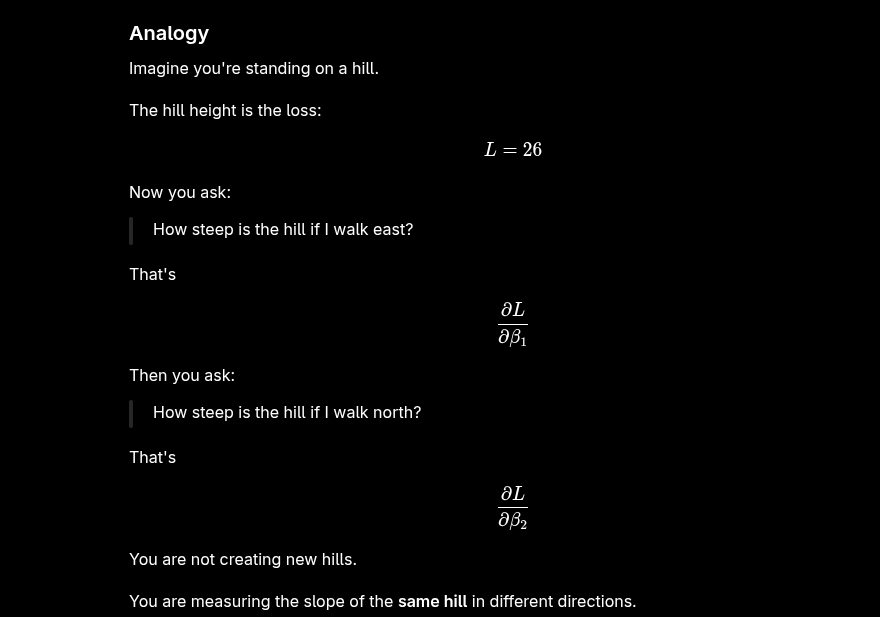

$$
\beta \textbf{ means the the slope in the direction of the  and we will descent or ascend in the that direction} 
$$

### Implimentation of it

In [60]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split


In [61]:
X,y=load_diabetes(return_X_y=True)

In [62]:
print(X.shape)

(442, 10)


In [63]:
print(y.shape)

(442,)


In [64]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)

In [65]:
reg = LinearRegression()
reg.fit(X_train,y_train)
out = reg.predict(X_test)
score  = r2_score(y_test,out)
print(score)

0.54569341370001


In [66]:
print(reg.coef_)
print(reg.intercept_)

[  -0.89288472 -243.70234493  542.27573143  324.09836107 -783.6806883
  595.97941645   30.48228652   -2.75711334  743.12475947   66.47145131]
153.64844563135648


In [67]:
print(np.ones(10))

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [68]:
print(X_train.shape[-1])

10


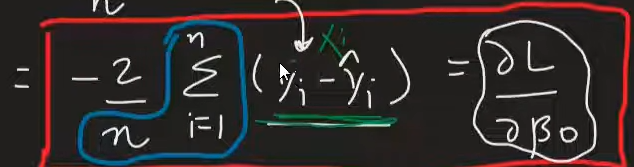

# **Revision**

## **Generalizing Multiple Linear Regression to \(m\) Features**

### Prediction for the First Training Example

$$
\hat{y}_1
=
\beta_0
+
\beta_1x_{11}
+
\beta_2x_{12}
+
\beta_3x_{13}
$$

### Prediction for the Second Training Example

$$
\hat{y}_2
=
\beta_0
+
\beta_1x_{21}
+
\beta_2x_{22}
+
\beta_3x_{23}
$$

### Prediction for the \(i^{th}\) Training Example

$$
\hat{y}_i
=
\beta_0
+
\sum_{m=1}^{p}
\beta_m x_{im}
$$

### Vector Form

$$
\hat{y}
=
\beta_0
+
\begin{bmatrix}
x_{11} & x_{12} & x_{13}
\end{bmatrix}
\begin{bmatrix}
\beta_1 \\
\beta_2 \\
\beta_3
\end{bmatrix}
$$

### Matrix Representation

$$
X=
\begin{bmatrix}
x_{11} & x_{12} & x_{13}\\
x_{21} & x_{22} & x_{23}\\
\vdots & \vdots & \vdots\\
x_{n1} & x_{n2} & x_{n3}
\end{bmatrix}
$$

$$
\boldsymbol{\beta}
=
\begin{bmatrix}
\beta_1\\
\beta_2\\
\beta_3
\end{bmatrix}
$$

$$
\hat{\mathbf y}
=
\beta_0\mathbf 1
+
X\boldsymbol{\beta}
$$

## **Gradient of the Loss Function**

The Mean Squared Error Loss is:

$$
L
=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat y_i)^2
$$

### Gradient with respect to \(\beta_m\)

$$
\frac{\partial L}{\partial \beta_m}
=
-\frac{2}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)x_{im}
$$

### Gradient Descent Update Rule

$$
\beta_m
=
\beta_m
-
\eta
\left(
\frac{\partial L}{\partial \beta_m}
\right)
$$

Substituting the gradient:

$$
\beta_m
=
\beta_m
+
\eta
\frac{2}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)x_{im}
$$

# The way to get the $\beta_1,\beta_2.........\beta_n$ directly

# Gradient Descent for Multiple Linear Regression

## Example Dataset

$$
X=
\begin{bmatrix}
1 & 2\\
3 & 4
\end{bmatrix}
$$

$$
y=
\begin{bmatrix}
5\\
7
\end{bmatrix}
$$

$$
\hat y=
\begin{bmatrix}
6\\
8
\end{bmatrix}
$$

$$
y-\hat y=
\begin{bmatrix}
-1\\
-1
\end{bmatrix}
$$

## Gradient of the Intercept

$$
\frac{\partial L}{\partial b}
=
-\frac{2}{n}
\sum_{i=1}^{n}(y_i-\hat y_i)
$$

Substituting:

$$
\frac{\partial L}{\partial b}
=
-\frac{2}{2}
(-1-1)
$$

$$
=
-\frac{2}{2}
(-2)
$$

$$
=2
$$

$$
\boxed{
\frac{\partial L}{\partial b}=2
}
$$

## Gradient of the Coefficients

$$
\frac{\partial L}{\partial \beta}
=
-\frac{2}{n}
X^T(y-\hat y)
$$

### Step 1

$$
X^T=
\begin{bmatrix}
1 & 3\\
2 & 4
\end{bmatrix}
$$

### Step 2

$$
X^T(y-\hat y)
=
\begin{bmatrix}
1 & 3\\
2 & 4
\end{bmatrix}
\begin{bmatrix}
-1\\
-1
\end{bmatrix}
$$

$$
=
\begin{bmatrix}
(1)(-1)+(3)(-1)\\
(2)(-1)+(4)(-1)
\end{bmatrix}
$$

$$
=
\begin{bmatrix}
-4\\
-6
\end{bmatrix}
$$

### Step 3

$$
-\frac{2}{2}
\begin{bmatrix}
-4\\
-6
\end{bmatrix}
=
\begin{bmatrix}
4\\
6
\end{bmatrix}
$$

$$
\boxed{
\frac{\partial L}{\partial \beta}
=
\begin{bmatrix}
4\\
6
\end{bmatrix}
}
$$

## Final Result

$$
\boxed{
\frac{\partial L}{\partial b}=2
}
$$

$$
\boxed{
\frac{\partial L}{\partial \beta}
=
\begin{bmatrix}
4\\
6
\end{bmatrix}
}
$$

In [123]:
class GDRegressor():
    def __init__(self,learning_rate=0.01,epochs=100):
        self.coef_=None
        self.intercept_ =None
        self.epochs= epochs
        self.lr = learning_rate
    def fit(self,X_train,y_train):
        self.X_train = X_train
        self.y_train  =  y_train

        # init your coeffecients
        self.intercept_ = 0
        # since we initilize the coeff as 1
        # the shape will be same as the size of the X_train
        self.coef_  = np.ones(X_train.shape[-1])
        for i in range(self.epochs):
            #now we wil update the intercept and the coefficient in the  loop
            #self.intercept_  = self.intercept - self.lr*intercept_der
            # see the above expression
            # take i =1
            # Y_1 is the Y train y 1 hat is the predict that we will get when  we had the mentioned slope and the intercept when we will subtract  it is aain some number we will all of them till n then we will devide it so it will become the mean
            y_hat = np.dot(X_train, self.coef_) + self.intercept_
            #print(y_hat)
            intercept_der = (-2/X_train.shape[0]) * np.sum(y_train - y_hat)
            #self.coeff_ = self.coeff_ -(self.lr*coeff_der)
            # now the coeff_der will be a [1X10] mateix in this case self.coff_ we have already initilized it so it will be  again a matrix of 1X10
            # now our task is to compute that 1X10 matrix like all the deratives wrt to bita_1 bita_2 .... bita_10
            coef_der = (-2/X_train.shape[0]) * np.dot(X_train.T, (y_train - y_hat))
            self.intercept_ = self.intercept_ -self.lr*intercept_der
            self.coef_ = self.coef_ - (self.lr*coef_der)
        print("Model has been  trained")
    def predict(self,X_test):
        # from above  we will get the all the betas and the coeff so we will multiply the all the X_test*bitas + intercept
        return np.dot(X_test,self.coef_)+self.intercept_



In [132]:
gdr = GDRegressor(learning_rate=0.9,epochs=1000)
gdr.fit(X_train,y_train)
out = gdr.predict(X_test)

Model has been  trained


In [133]:
score = r2_score(y_test,out)
print(score)

0.5476253592502539


In [ ]:
class GDRegressor():
    def __init__(self,learning_rate=0.01,epochs=100):
        self.coef_=None
        self.intercept_ =None
        self.epochs= epochs
        self.lr = learning_rate
    def fit(self,X_train,y_train):
        self.X_train = X_train
        self.y_train  =  y_train
        self.intercept_ = 0
        self.coef_  = np.ones(X_train.shape[-1])
        for i in range(self.epochs):
            y_hat = np.dot(X_train, self.coef_) + self.intercept_
            intercept_der = (-2/X_train.shape[0]) * np.sum(y_train - y_hat)
            #self.coeff_ = self.coeff_ -(self.lr*coeff_der)
            # now the coeff_der will be a [1X10] mateix in this case self.coff_ we have already initilized it so it will be  again a matrix of 1X10
            # now our task is to compute that 1X10 matrix like all the deratives wrt to bita_1 bita_2 .... bita_10
            coef_der = (-2/X_train.shape[0]) * np.dot(X_train.T, (y_train - y_hat))
            self.intercept_ = self.intercept_ -self.lr*intercept_der
            self.coef_ = self.coef_ - (self.lr*coef_der)
        print("Model has been  trained")
    def predict(self,X_test):
        # from above  we will get the all the betas and the coeff so we will multiply the all the X_test*bitas + intercept
        return np.dot(X_test,self.coef_)+self.intercept_

